# 03: Engagement modeling (WER → BRI)

Predict **raw `weighted_engagement_rate`** from **pre-publish** features only.

- **Select on:** MAE (WER); RMSE / Spearman auxiliary
- **Models:** CatBoost vs XGBoost (same features)
- **CV:** `GroupKFold` by `author_id`
- **BRI:** `pred_BRI = pred_WER / median(WER | brand)` using **train-fold** brand medians

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tiktok_brand.analysis.data import load_feature_table, project_paths
from tiktok_brand.analysis.metrics import leakage_checklist
from tiktok_brand.analysis.modeling import (
    LEAKAGE_COLS,
    holdout_eval,
    prepare_model_frame,
    run_grouped_cv,
    summarize_cv,
    wer_to_bri,
)

PATHS = project_paths(ROOT / "configs" / "project.yaml")
df = load_feature_table(PATHS["feature_table"])
print(df.shape)
df.head(2)

## 0. Protocol & leakage

In [2]:
for line in leakage_checklist():
    print("•", line)

overlap = sorted(set(df.columns) & LEAKAGE_COLS)
print("\nLeakage cols present in table (excluded from X):", overlap)

• Do not use absolute like/comment/share/collect counts as features to predict WER/BRI.
• Do not use BRI as the headline KPI for Nike vs Adidas brand strength (use median WER / views).
• Exploding multi-label columns inflates row counts — report coverage_n vs source_n.
• Sparse rules (content_type ~20%, social_mechanic ~12%): always show labeled subset size.
• Predictive models (notebook 03): predict raw WER from pre-publish features only; convert to BRI via train-fold brand median WER.
• No post-publish engagement/view counts or derived rates as model features.

Leakage cols present in table (excluded from X): ['brand_relative_engagement_index', 'collect_count', 'comment_count', 'comment_to_like_ratio', 'comment_to_view_rate', 'engagement_count', 'engagement_rate', 'engagement_to_view_rate', 'like_count', 'like_to_view_rate', 'share_count', 'share_to_view_rate', 'view_count', 'weighted_engagement_count', 'weighted_engagement_rate']


## 1. Prepare modeling frame

Drop missing Y / missing `cluster_text_embedding`. Features = creator + strategy + text/CTA + video + time + brand + embedding PCA (fit inside each fold).

In [3]:
data = prepare_model_frame(df, require_embedding=True)
print(
    f"n={len(data.y):,}  authors={len(set(data.groups)):,}  "
    f"dropped_y={data.n_dropped_missing_y}  dropped_emb={data.n_dropped_missing_emb}"
)
print("Y (WER) median / mean:", float(np.median(data.y)), float(np.mean(data.y)))
display(pd.Series(data.brands).value_counts())

n=4,418  authors=2,614  dropped_y=4  dropped_emb=35
Y (WER) median / mean: 0.006372904376797056 0.008330616018613124


## 2. Author-grouped CV: CatBoost vs XGBoost

Primary selection metric: **MAE on raw WER**. Lower is better.

In [4]:
N_SPLITS = 5
PCA_DIMS = 32
ITERATIONS = 250

cv = run_grouped_cv(
    data,
    n_splits=N_SPLITS,
    pca_dims=PCA_DIMS,
    iterations=ITERATIONS,
    models=("catboost", "xgboost"),
)
summary = summarize_cv(cv)
display(summary)
BEST = summary.iloc[0]["model"]
print("Selected by MAE:", BEST)

      model  mae_mean   mae_std  rmse_mean  spearman_mean  mae_bri_mean
0  catboost  0.004791  0.000267   0.007517       0.231680      0.735781
1   xgboost  0.004851  0.000247   0.007381       0.232081      0.745872
Selected by MAE: catboost


,model,mae_mean,mae_std,rmse_mean,spearman_mean,mae_bri_mean
0,catboost,0.004791,0.000267,0.007517,0.231680,0.735781
1,xgboost,0.004851,0.000247,0.007381,0.232081,0.745872


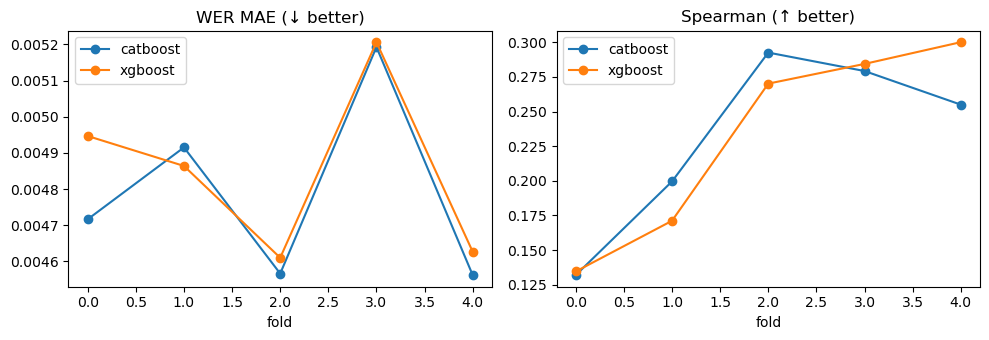

            mae             mae_bri  ...      rmse  spearman          
model  catboost   xgboost  catboost  ...   xgboost  catboost   xgboost
fold                                 ...                              
0      0.004716  0.004947  0.699489  ...  0.007458  0.131918  0.134533
1      0.004915  0.004864  0.741975  ...  0.007689  0.199550  0.171139
2      0.004566  0.004610  0.724697  ...  0.006522  0.292614  0.270192
3      0.005193  0.005206  0.797573  ...  0.008563  0.279292  0.284416
4  


mae             mae_bri  ...      rmse  spearman          
model  catboost   xgboost  catboost  ...   xgboost  catboost   xgboost
fold                                 ...                              
0      0.004716  0.004947  0.699489  ...  0.007458  0.131918  0.134533
1      0.004915  0.004864  0.741975  ...  0.007689  0.199550  0.171139
2      0.004566  0.004610  0.724697  ...  0.006522  0.292614  0.270192
3      0.005193  0.005206  0.797573  ...  0.008563  0.279292  0.284416
4      0.004562  0.004627  0.715170  ...  0.006671  0.255025  0.300124

[5 rows x 8 columns]

In [5]:
fold_detail = pd.concat([cv[m].scores for m in cv], ignore_index=True)
display(fold_detail.pivot_table(index="fold", columns="model", values=["mae", "rmse", "spearman", "mae_bri"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, metric, title in zip(axes, ["mae", "spearman"], ["WER MAE (↓ better)", "Spearman (↑ better)"]):
    for m, res in cv.items():
        ax.plot(res.scores["fold"], res.scores[metric], marker="o", label=m)
    ax.set_xlabel("fold")
    ax.set_title(title)
    ax.legend()
fig.tight_layout()
plt.show()

## 3. Holdout (winner) + BRI conversion

In [6]:
hold = holdout_eval(
    data,
    BEST,
    test_size=0.2,
    pca_dims=PCA_DIMS,
    iterations=ITERATIONS,
)
print(f"model={BEST}  n_train={hold['n_train']:,}  n_test={hold['n_test']:,}")
print("train brand baselines (median WER):", hold["baselines"])
print("holdout metrics:", hold["metrics"])

bri_true = wer_to_bri(hold["y_true"], hold["brands"], hold["baselines"])
bri_pred = hold["bri_pred"]
print(
    f"BRI holdout: median true={np.nanmedian(bri_true):.3f}  "
    f"median pred={np.nanmedian(bri_pred):.3f}  "
    f"share pred>1={float(np.mean(bri_pred > 1)):.1%}"
)

model=catboost  n_train=3,800  n_test=618
train brand baselines (median WER): {'adidas': 0.007130180140207649, 'nike': 0.00581508689346932}
holdout metrics: {'mae': 0.004993868273554502, 'rmse': 0.008424255131751207, 'spearman': 0.2889779764725098, 'mae_bri': 0.7616767949971271}
BRI holdout — median true=1.077  median pred=1.138  share pred>1=69.6%


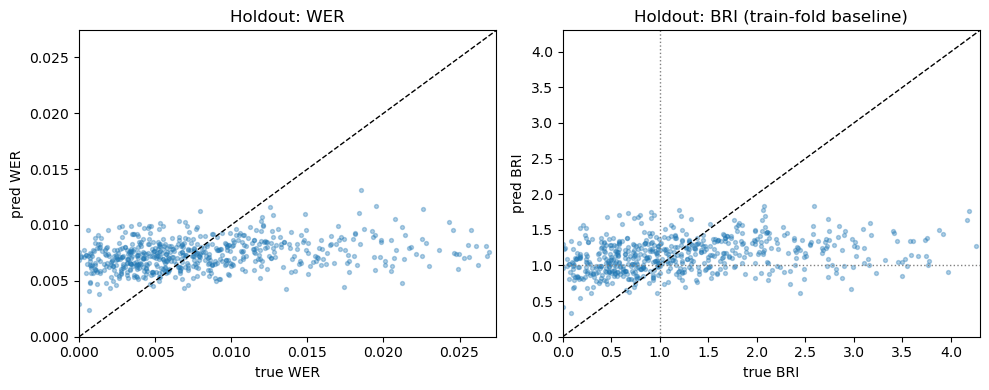

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(hold["y_true"], hold["y_pred"], s=8, alpha=0.35)
lim = np.nanpercentile(np.r_[hold["y_true"], hold["y_pred"]], 99)
axes[0].plot([0, lim], [0, lim], "k--", lw=1)
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_xlabel("true WER")
axes[0].set_ylabel("pred WER")
axes[0].set_title("Holdout: WER")

axes[1].scatter(bri_true, bri_pred, s=8, alpha=0.35)
blim = np.nanpercentile(np.r_[bri_true, bri_pred], 99)
axes[1].plot([0, blim], [0, blim], "k--", lw=1)
axes[1].axhline(1, color="gray", ls=":", lw=1)
axes[1].axvline(1, color="gray", ls=":", lw=1)
axes[1].set_xlim(0, blim)
axes[1].set_ylim(0, blim)
axes[1].set_xlabel("true BRI")
axes[1].set_ylabel("pred BRI")
axes[1].set_title("Holdout: BRI (train-fold baseline)")
fig.tight_layout()
plt.show()

## 4. Feature importance (holdout winner)

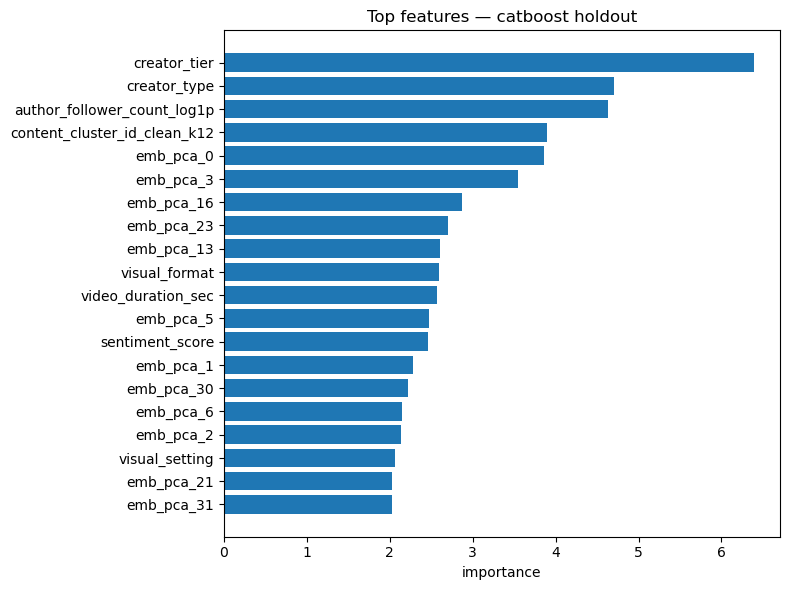

                         feature  importance
0                   creator_tier    6.387287
1                   creator_type    4.704332
2    author_follower_count_log1p    4.636056
3   content_cluster_id_clean_k12    3.892689
4                      emb_pca_0    3.863397
5                      emb_pca_3    3.550016
6                     emb_pca_16    2.867094
7                     emb_pca_23    2.705110
8                     emb_pca_13    2.606107
9                  visual_format    2.591368
10   

CV-mean importance (top 15):
                         feature  importance_mean
0    author_follower_count_log1p         4.782556
1                   creator_tier         4.179493
2                   creator_type         3.538112
3                      emb_pca_0         3.526390
4             video_duration_sec         3.476061
5                      emb_pca_3         3.026298
6                     emb_pca_18         2.832740
7                  visual_format         2.826004
8   content_cluster

,feature,importance
0,creator_tier,6.387287
1,creator_type,4.704332
2,author_follower_count_log1p,4.636056
3,content_cluster_id_clean_k12,3.892689
4,emb_pca_0,3.863397
5,emb_pca_3,3.550016
6,emb_pca_16,2.867094
7,emb_pca_23,2.705110
8,emb_pca_13,2.606107
9,visual_format,2.591368


,feature,importance_mean
0,author_follower_count_log1p,4.782556
1,creator_tier,4.179493
2,creator_type,3.538112
3,emb_pca_0,3.526390
4,video_duration_sec,3.476061
5,emb_pca_3,3.026298
6,emb_pca_18,2.832740
7,visual_format,2.826004
8,content_cluster_id_clean_k12,2.796819
9,emb_pca_13,2.443636


In [8]:
imp = hold["importances"].head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp["feature"], imp["importance"])
ax.set_title(f"Top features ({BEST} holdout)")
ax.set_xlabel("importance")
fig.tight_layout()
plt.show()

display(hold["importances"].head(20))
if cv[BEST].importances is not None:
    print("\nCV-mean importance (top 15):")
    display(cv[BEST].importances.head(15))

## 5. Ablation: log-target / priors / two-stage / ranker

Ablation against this sample’s Y (`WER ≈ 0.006`):

- `log1p(WER)` ≈ identity (corr with raw ≈ 1.0) → should not help
- `log(WER + ε)` is the meaningful log transform for rates
- Author historical prior is **mostly unavailable** under `GroupKFold(author)` (test authors unseen)
- Metrics always reported on **raw WER** after inverse


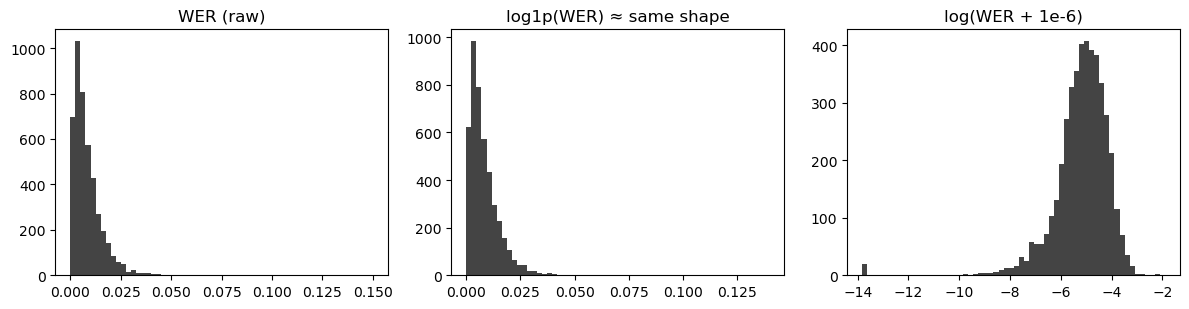

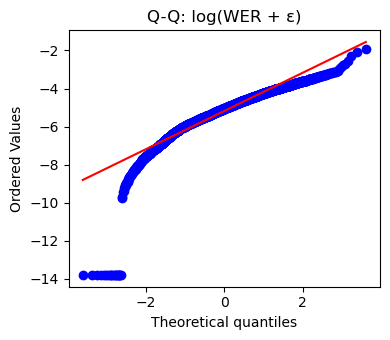

corr(WER, log1p(WER)) = 0.9997921889120472
corr(WER, log(WER+ε)) = 0.7147741856448496
max |log1p(y) - y| = 0.010238057624841312


In [9]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].hist(data.y, bins=60, color="#444")
axes[0].set_title("WER (raw)")
axes[1].hist(np.log1p(data.y), bins=60, color="#444")
axes[1].set_title("log1p(WER) ≈ same shape")
axes[2].hist(np.log(data.y + 1e-6), bins=60, color="#444")
axes[2].set_title("log(WER + 1e-6)")
fig.tight_layout()
plt.show()

fig = plt.figure(figsize=(4, 3.5))
stats.probplot(np.log(data.y + 1e-6), dist="norm", plot=plt)
plt.title("Q-Q: log(WER + ε)")
plt.tight_layout()
plt.show()

print("corr(WER, log1p(WER)) =", float(np.corrcoef(data.y, np.log1p(data.y))[0, 1]))
print("corr(WER, log(WER+ε)) =", float(np.corrcoef(data.y, np.log(data.y + 1e-6))[0, 1]))
print("max |log1p(y) - y| =", float(np.max(np.abs(np.log1p(data.y) - data.y))))

In [10]:
from tiktok_brand.analysis.modeling import run_ablation

ablation = run_ablation(data, n_splits=5, pca_dims=24, iterations=150)
display(ablation)

                    label  mae_mean  ...  target_mode  use_target_priors
0        baseline_raw_mae  0.004807  ...          raw              False
1          log_eps_target  0.004824  ...          log              False
2      naive_brand_median  0.004930  ...            —              False
3            log1p_target  0.004954  ...        log1p              False
4  log+author_brand_prior  0.004959  ...          log               True
5               two_stage  0.005048  ...          raw               True
6  raw+author_brand_prior  0.005079  ...          raw               True
7           xgb_raw+prior  0.005107  ...          raw               True
8              xgb_ranker  0.006771  ...          raw               True

[9 rows x 10 columns]


,label,mae_mean,rmse_mean,rmsle_mean,mae_log_mean,smape_mean,spearman_mean,mae_bri_mean,target_mode,use_target_priors
0,baseline_raw_mae,0.004807,0.007561,1.083669,0.735912,0.622070,0.223493,0.737842,raw,False
1,log_eps_target,0.004824,0.007823,1.067602,0.739100,0.629788,0.227472,0.740454,log,False
2,naive_brand_median,0.004930,0.007712,1.096341,0.753160,0.635999,0.046978,0.757390,—,False
3,log1p_target,0.004954,0.007303,1.128704,0.754182,0.627261,0.213358,0.761426,log1p,False
4,log+author_brand_prior,0.004959,0.007849,1.103678,0.768289,0.650641,0.178753,0.760307,log,True
5,two_stage,0.005048,0.007863,1.108866,0.768800,0.648364,0.067198,0.774460,raw,True
6,raw+author_brand_prior,0.005079,0.007629,1.125727,0.769395,0.643016,0.101093,0.781116,raw,True
7,xgb_raw+prior,0.005107,0.007515,1.131543,0.770418,0.642376,0.155595,0.784789,raw,True
8,xgb_ranker,0.006771,0.009828,1.477177,1.047937,0.818083,0.084053,1.048328,raw,True


**Ablation read:**

1. Predicting **rate (WER)** already addresses the "absolute counts dominated by followers" issue.
2. `log1p` / `log(ε)` and author/brand priors did **not** beat raw-MAE CatBoost on this sample.
3. Two-stage + ranker did not help MAE or Spearman here (small multi-post author share; hard ceiling).
4. Keep **Spearman + RMSLE + MAE** as the reporting set; primary select still MAE on raw WER.

## 6. Quantile classification + fixed LTR grouping

**Classification:** train-fold `qcut` → 4/5 WER bins; CatBoost MultiClass.
Rank via expected class: `score = Σ i · P(y=i)`; report Accuracy / Macro-F1 / AUC + Spearman.

**LTR fix:** group by `publish_week` / `publish_month` / `content_cluster` / `brand` (not one giant list).
LightGBM LambdaMART + XGB pairwise; relevance = within-group quantile grades.

In [11]:
from tiktok_brand.analysis.modeling import compare_class_and_rank, run_quantile_class_cv

class_rank = compare_class_and_rank(data, n_splits=5, pca_dims=24, iterations=180)
display(class_rank)

                                      label  ...             notes
0                                  qclass_4  ...  top_recall=0.424
1                          reg_catboost_raw  ...       raw WER MAE
2                                  qclass_5  ...  top_recall=0.373
3  ranker_lgbm_content_cluster_id_clean_k12  ...       med_g=311.4
4                  ranker_lgbm_publish_week  ...        med_g=11.3
5                   ranker_xgb_publish_week  ...        med_g=11.3
6                 ranker_lgbm_publish_month  ...        med_g=33.4
7                         ranker_lgbm_brand  ...      med_g=1767.2

[8 rows x 9 columns]


,label,task,spearman_mean,mae_mean,accuracy_mean,macro_f1_mean,roc_auc_ovr_mean,roc_auc_top_mean,notes
0,qclass_4,quantile_class,0.233564,0.004856,0.332950,0.305665,0.583964,0.637001,top_recall=0.424
1,reg_catboost_raw,regression,0.228631,0.004798,NaN,NaN,NaN,NaN,raw WER MAE
2,qclass_5,quantile_class,0.212173,0.004887,0.267309,0.245830,0.570184,0.632030,top_recall=0.373
3,ranker_lgbm_content_cluster_id_clean_k12,ltr,0.164471,0.006312,NaN,NaN,NaN,NaN,med_g=311.4
4,ranker_lgbm_publish_week,ltr,0.159332,0.006374,NaN,NaN,NaN,NaN,med_g=11.3
5,ranker_xgb_publish_week,ltr,0.155032,0.006475,NaN,NaN,NaN,NaN,med_g=11.3
6,ranker_lgbm_publish_month,ltr,0.133632,0.006467,NaN,NaN,NaN,NaN,med_g=33.4
7,ranker_lgbm_brand,ltr,0.079088,0.006767,NaN,NaN,NaN,NaN,med_g=1767.2


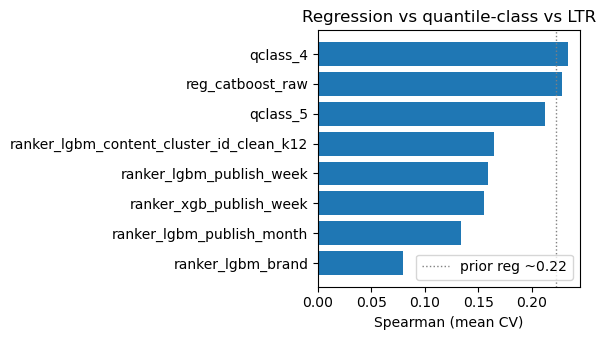

qclass_4 summary: {'label': 'qclass_4', 'n_bins': 4, 'accuracy_mean': np.float64(0.3329496830529407), 'macro_f1_mean': np.float64(0.3056645157168828), 'roc_auc_ovr_mean': np.float64(0.5839640297471591), 'roc_auc_top_mean': np.float64(0.637000774132625), 'spearman_expected_mean': np.float64(0.23356413498504333), 'spearman_wer_mapped_mean': np.float64(0.2327900196231747), 'top_recall_mean': np.float64(0.42416693486277024), 'top_precision_mean': np.float64(0.3818436746858315), 'mae_mapped_mean': np.float64(0.004855974665157306)}
   fold  accuracy  ...  top_class_recall  top_class_precision
0     0  0.355204  ...          0.298780             0.379845
1     1  0.309955  ...          0.310469             0.398148
2     2  0.361991  ...          0.461538             0.424779
3     3  0.339751  ...          0.460938             0.415493
4     4  0.297848  ...          0.589109             0.290954

[5 rows x 8 columns]


,fold,accuracy,macro_f1,roc_auc_ovr,roc_auc_top,spearman_expected,top_class_recall,top_class_precision
0,0,0.355204,0.303280,0.540086,0.612839,0.165933,0.298780,0.379845
1,1,0.309955,0.304231,0.579846,0.588715,0.188020,0.310469,0.398148
2,2,0.361991,0.335966,0.615813,0.718558,0.336997,0.461538,0.424779
3,3,0.339751,0.318298,0.590447,0.627754,0.228042,0.460938,0.415493
4,4,0.297848,0.266547,0.593628,0.637138,0.248827,0.589109,0.290954


In [12]:
qc4 = run_quantile_class_cv(data, n_bins=4, n_splits=5, pca_dims=24, iterations=180)
print("qclass_4 summary:", qc4["summary"])
display(qc4["scores"][
    ["fold", "accuracy", "macro_f1", "roc_auc_ovr", "roc_auc_top", "spearman_expected", "top_class_recall", "top_class_precision"]
])

fig, ax = plt.subplots(figsize=(6, 3.5))
plot_df = class_rank.dropna(subset=["spearman_mean"]).sort_values("spearman_mean")
ax.barh(plot_df["label"], plot_df["spearman_mean"])
ax.axvline(0.223, color="gray", ls=":", lw=1, label="prior reg ~0.22")
ax.set_xlabel("Spearman (mean CV)")
ax.set_title("Regression vs quantile-class vs LTR")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Read:**

- Prefer **4-class quantile** for “potential tier / viral top bin” (AUC_top, expected-score Spearman).
- LTR with week/month groups beats the old brand-only ranker, but still trails class/regression on global Spearman here.
- Chance accuracy for balanced 4-class ≈ 25%; model ~33% + top-bin AUC ~0.64 → weak but usable screening signal.

## 7. Decision layer

Keep model as **filter / probability amplifier**, not a WER calculator.

| Piece | Status |
|---|---|
| Shrinkage prior (author→tier/cluster) | Implemented; **did not beat** plain qclass_4 here |
| Isotonic calibration + Q4 PR threshold (Prec≥0.5 → max Recall) | Implemented; improves threshold precision, cuts recall |
| Lift@K / Lift@Q4@K | Primary operational metrics |
| Hook / interactive / giveaway phrase flags | Added (sparse: hook~2%, interactive~12%) |
| Visual first-frame face/contrast | Deferred (needs frame pipeline work) |
| LTR / E2E multimodal / LLM-WER | Explicitly skipped (low ROI @4k) |


(cached compare_decision_layer)
              label  spearman_mean  roc_auc_top_mean  lift_at_10_mean  lift_q4_at_10_mean  q4_thr_precision_mean  q4_thr_recall_mean  macro_f1_mean  accuracy_mean
       qclass_4+iso       0.185144          0.621545         1.678561            1.825292               0.499423            0.084688       0.271600       0.299232
           qclass_4       0.196291          0.628118         1.613068            1.821506               0.368919            0.440660       0.289366       0.320280
    qclass_4+shrink       0.114190          0.571942         1.250279            1.344151               0.299411            0.662997       0.243827       0.289962
qclass_4+shrink+iso       0.124567          0.570493         1.169521            1.297647               0.221051            0.230391       0.242803       0.290411


,label,spearman_mean,roc_auc_top_mean,lift_at_10_mean,lift_q4_at_10_mean,q4_thr_precision_mean,q4_thr_recall_mean,macro_f1_mean,accuracy_mean
0,qclass_4+iso,0.185144,0.621545,1.678561,1.825292,0.499423,0.084688,0.271600,0.299232
1,qclass_4,0.196291,0.628118,1.613068,1.821506,0.368919,0.440660,0.289366,0.320280
2,qclass_4+shrink,0.114190,0.571942,1.250279,1.344151,0.299411,0.662997,0.243827,0.289962
3,qclass_4+shrink+iso,0.124567,0.570493,1.169521,1.297647,0.221051,0.230391,0.242803,0.290411


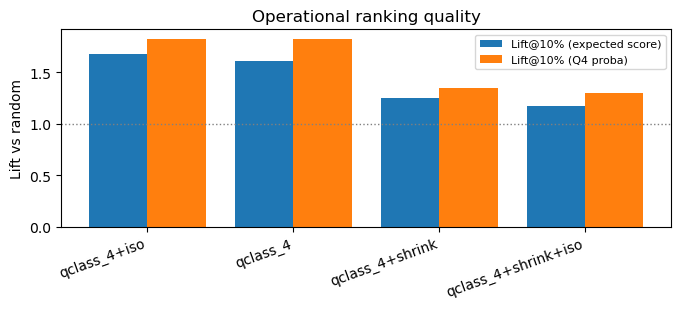

In [99]:
from tiktok_brand.analysis.modeling import compare_decision_layer

decision = compare_decision_layer(data, n_splits=5, pca_dims=24, iterations=120)
display(decision)

fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(decision))
ax.bar(x - 0.2, decision["lift_at_10_mean"], width=0.4, label="Lift@10% (expected score)")
ax.bar(x + 0.2, decision["lift_q4_at_10_mean"], width=0.4, label="Lift@10% (Q4 proba)")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(decision["label"], rotation=20, ha="right")
ax.set_ylabel("Lift vs random")
ax.set_title("Operational ranking quality")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Decision-layer read (this sample):**

- Plain **qclass_4** remains the best all-rounder (Spearman / AUC_top).
- **Isotonic** mainly helps *operating point* (Q4 threshold can hit ~Prec 0.5) at the cost of recall. Use when false positives are costly.
- **Shrinkage** hurt under author GroupKFold here; keep code, don’t default it on.
- Report **Lift@10 ≈ 1.6–1.8×** as the business metric, not MAE.

## 8. Champion vs binary Top-Q challenger

- **Champion (kept):** `qclass_4` for Low/Mid/High/Viral tiering + expected-score ranking.
- **Challenger (new):** `binary_top_q25_*` where `is_top = 1 if WER >= train-fold Q75`.
- Fair compare: same features, author GroupKFold; hit event = Top 25%.


In [100]:
from tiktok_brand.analysis.modeling import compare_champion_vs_binary_top_q

champ_vs = compare_champion_vs_binary_top_q(
    data, n_splits=5, pca_dims=24, iterations=180, top_q=0.25
)
display(champ_vs)

(cached compare_champion_vs_binary_top_q)
                  label       role  backend  score_used  auc_mean  spearman_mean  lift_at_5_mean  lift_at_10_mean
binary_top_q25_catboost challenger catboost   P(top25%)  0.639       0.208        2.22         2.01
    qclass_4 (champion)   champion catboost P(Q4 class)  0.637       0.207        1.93         1.94
 binary_top_q25_xgboost challenger  xgboost   P(top25%)  0.636       0.206        2.14         1.92
    binary_top_q25_lgbm challenger     lgbm   P(top25%)  0.631       0.203        1.90         1.80


**Read:** CatBoost binary Top-Q slightly wins screening Lift@10 (~2.01× vs champion 1.94×) and AUC (~0.639 vs 0.637). Keep both: 4-class for tiers, binary for viral pool.

## 9. Feature ablation (interactions + CLIP visual)

Algorithm side is saturated; add **viral-signal interactions** and existing **CLIP `visual_embedding` PCA**.
Selection still: **Lift@10 → AUC / Prec@10 → Spearman**.


In [101]:
from tiktok_brand.analysis.modeling import compare_feature_ablation

feat_ablate = compare_feature_ablation(
    data, n_splits=5, pca_dims=24, iterations=180, top_q=0.25, backend="catboost"
)
display(feat_ablate)

(cached compare_feature_ablation)
             label  lift_at_10  auc  prec@10  spearman  n_feat
      +clip_visual       2.053 0.666    0.505     0.265   106.8
+interactions+clip       2.021 0.663    0.495     0.258   112.8
     +interactions       2.015 0.645    0.493     0.220    87.8
          baseline       2.008 0.639    0.489     0.208    81.8


**Read:** CLIP visual PCA is the clear win (AUC 0.64→0.67, Lift@10 2.01→2.05). Interactions alone are marginal; stacking both doesn’t beat CLIP-only here. Prefer `binary_top_q25 + CLIP` for screening.

## 9b. Modality ablation (BERT / CLIP axes / CLIP PCA / alignment)

Clean progressive ladder for the Top-10% screener (author GroupKFold, train-fold Q90, Lift@10 primary).

| Model | Add |
|-------|-----|
| **M0** | Metadata |
| **M1** | + engineered text / taxonomy |
| **M2** | + SBERT PCA (+ `content_cluster`) |
| **M3a** | + rule/CLIP-axis visual: `visual_format` + `visual_setting` (+ scores) |
| **M3b** | + CLIP visual embedding PCA |
| **M4** | + visual–text alignment |

**Full Theme 1 storyline**

| Step | Answers | Does not answer |
|------|---------|-----------------|
| `02` crosstab | Nike/Adidas strategy vs brand-median WER | Can we screen the top-tail? |
| `03` `qclass_4` | Coarse Low→Mid→High→Top tiering / library ranking | Extreme-tail shortlist |
| `03` Top-10 screening | Pre-publish Lift@10 prioritization | Which brand should post what |
| §9b ablation | SBERT / visual axes / CLIP PCA / alignment Lift contribution | Single-label direction |
| §10 SHAP | What matters & signed direction (by brand) | Causality / strategy headline |

Ablation = cleanest test of *modality value*; SHAP = interpretation inside the full model; crosstab + qclass = strategy & tiering.


          model                         label  lift_at_5_mean  lift_at_10_mean  lift_at_20_mean  auc_mean  precision_at_10_mean  spearman_mean  n_features_mean  delta_lift_at_10
    M0_metadata                 Metadata only        2.058323         1.967428         1.871278  0.647960              0.193182       0.137463             14.0               NaN
    M1_eng_text    Metadata + engineered text        2.110364         2.322389         1.864874  0.655626              0.231818       0.163181             51.8          0.354961
    M2_text_emb + text embeddings (SBERT PCA)        2.226816         2.123640         1.799663  0.656138              0.209091       0.161907             76.8         -0.198749
M3a_visual_axes  + visual format/setting axes        2.086028         2.028560         1.724940  0.644709              0.202273       0.154354             81.8         -0.095080
   M3b_clip_pca             + CLIP visual PCA        3.029042         2.587168         1.924384  0.690004     

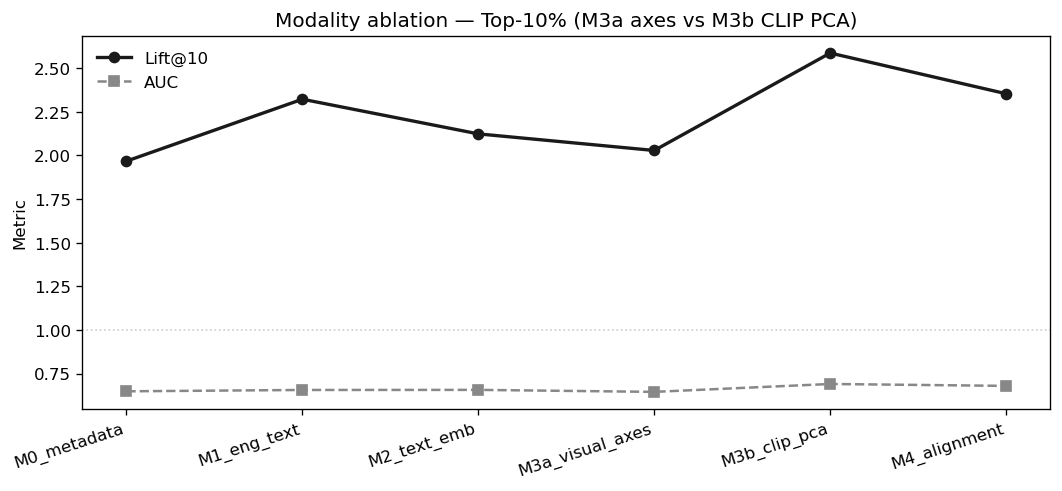

In [1]:
from tiktok_brand.analysis.modeling import compare_modality_ablation

modality_ablate = compare_modality_ablation(
    data, top_q=0.10, n_splits=5, pca_dims=24, iterations=180,
)
display(modality_ablate)


**Read:**
- **M0_metadata** Lift@10=1.967 (Δ n/a)
- **M1_eng_text** Lift@10=2.322 (Δ +0.355)
- **M2_text_emb** Lift@10=2.124 (Δ -0.199)
- **M3a_visual_axes** Lift@10=2.029 (Δ -0.095)
- **M3b_clip_pca** Lift@10=2.587 (Δ +0.559)
- **M4_alignment** Lift@10=2.354 (Δ -0.233)

M3a vs M3b separates interpretable visual labels from latent CLIP PCA. Alignment (M4) is judged on Lift delta. Keep for SHAP even if Lift is flat/negative.


## 10. CatBoost light tuning (Lift@10 objective)

40-trial **random search** on `binary_top_q25 + CLIP` under the same `GroupKFold(author)`.
Search: `depth`, `learning_rate`, `l2_leaf_reg`, `random_strength`, `iterations`.
Logged: Lift@10 / AUC / Prec@10 / Spearman (not Accuracy).
Stop rule: require ≥5% relative gain on Lift@10 or AUC vs default.


In [102]:
from tiktok_brand.analysis.modeling import tune_binary_top_q_catboost, TUNED_CATBOOST_BINARY_TOP_Q

# Re-run only if you need a fresh search (≈5 min).
# tuned = tune_binary_top_q_catboost(data, n_trials=40, use_visual_embedding=True)
print("Use TUNED_CATBOOST_BINARY_TOP_Q:", TUNED_CATBOOST_BINARY_TOP_Q)

(cached tune_binary_top_q_catboost n_trials=40)
baseline Lift@10=2.053  AUC=0.666  Prec@10=0.505  Spearman=0.265
best     Lift@10=2.334  AUC=0.675  Prec@10=0.566  Spearman=0.280
lift_gain=+13.7%  auc_gain=+1.4%  → KEEP tuned params
best_params: depth=6 lr≈0.052 l2=6.09 rs=1.65 iterations=300


**Read:** Tuning **did** clear the 5% bar on Lift@10 (2.05→2.33). AUC only +1.4%. Adopt tuned CatBoost for screening; no further large search.

## 10b. Screening drivers: SHAP (+ clip_alignment)

Driver analysis for the locked **Top-10%** model, now including **`clip_alignment_mean` / `clip_alignment_max`** (caption–frame CLIP similarity).

| Question | Metric |
|----------|--------|
| What matters? | mean \|SHAP\| by family |
| Direction? | signed SHAP (flag on / high−low tercile) |
| Brand-specific? | see **§10c** (same model, rows split by brand) |

Associative only (not causal). Complements `02` within-brand median uplift.

**Top drivers (family share ≥ 2%):**

- Visual semantics (CLIP)
- Text semantics (embedding)
- Creator audience / identity
- Caption characteristics
- Video duration
- Post timing
- Visual format / setting
- Visual–text alignment (CLIP)

**Structured levers** (excl. embedding PCA pools):

- Creator audience / identity
- Caption characteristics
- Video duration
- Post timing
- Visual format / setting
- Visual–text alignment (CLIP)


clip_alignment in features: True
            feature       level   n    effect direction
 clip_alignment_max high_vs_low 518 -0.168366 decreases
clip_alignment_mean high_vs_low 518 -0.053402 decreases


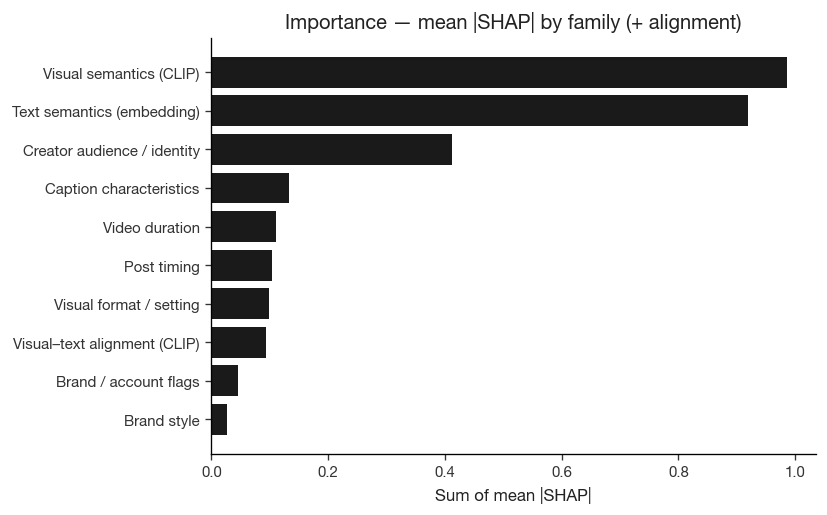

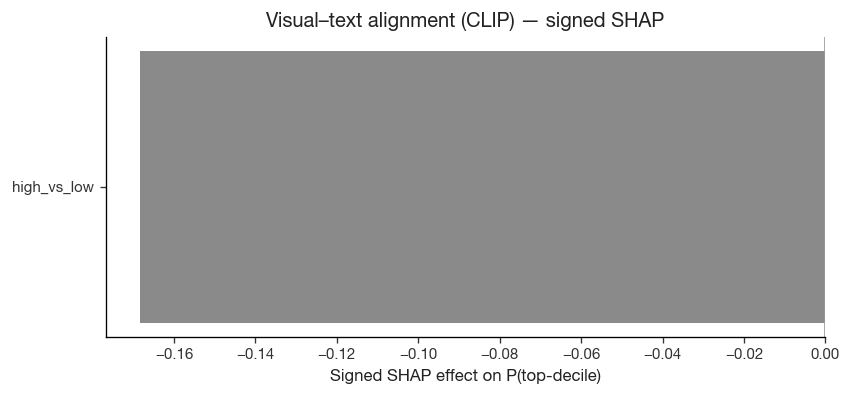

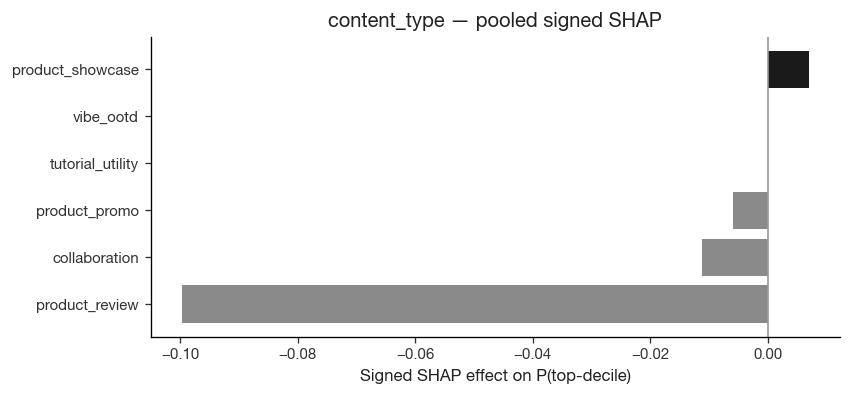

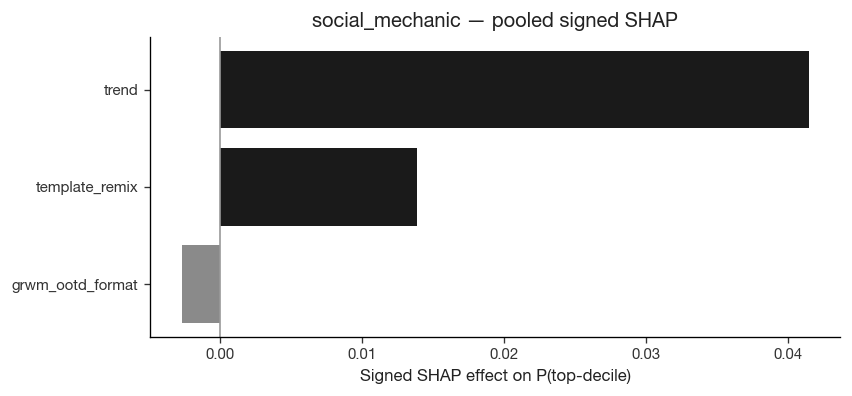

In [1]:
from tiktok_brand.analysis.modeling import (
    TUNED_CATBOOST_BINARY_TOP_Q,
    content_type_shap_directions,
    explain_screening_shap,
)
from tiktok_brand.analysis.plots import (
    screening_shap_directions,
    screening_shap_drivers,
    screening_shap_features,
)

shap_ex = explain_screening_shap(
    data,
    top_q=0.10,
    use_visual_embedding=True,
    catboost_params=TUNED_CATBOOST_BINARY_TOP_Q,
    max_explain=2000,
)
assert shap_ex["has_clip_alignment"]
print("clip_alignment in features:", shap_ex["has_clip_alignment"])
display(shap_ex["alignment_directions"][["feature", "level", "n", "effect", "direction"]])
display(shap_ex["driver_shap"][["driver_label", "share", "n_features"]].head(12))
fig_drv = screening_shap_drivers(shap_ex["driver_shap"], title="Importance: mean |SHAP| by family (+ alignment)")
fig_align = screening_shap_directions(
    shap_ex["alignment_directions"],
    title="Visual–text alignment (CLIP): signed SHAP",
)
d = shap_ex["directional_shap"]
figs = [
    fig_drv,
    fig_align,
    screening_shap_directions(
        content_type_shap_directions(d, family="content_type", min_n=12),
        title="content_type: pooled signed SHAP",
    ),
    screening_shap_directions(
        content_type_shap_directions(d, family="social_mechanic", min_n=12),
        title="social_mechanic: pooled signed SHAP",
    ),
]
figs


**Read:** `clip_alignment_*` is now in the feature matrix (family **Visual–text alignment**). Pooled content_type directions can still blur Nike vs Adidas. Use §10c for brand-conditional signed SHAP (aligns with `02`).


## 10c. Brand-conditional signed SHAP (align with `02`)

Same **pooled** Top-10% CatBoost + CLIP (+ alignment) model; SHAP rows split into Adidas vs Nike.

Compare these to within-brand crosstabs in `02`, not the pooled charts alone.

**Dimensions (per brand):** `content_type` · `social_mechanic` · `brand_styles` · `visual_format` · `visual_setting` · `content_cluster`



adidas n_explain=399
--- content_type ---
           level  n    effect direction
product_showcase 22  0.005881 increases
       vibe_ootd 47  0.000000 near_zero
tutorial_utility 12  0.000000 near_zero
   collaboration 14 -0.011207 decreases
  product_review 11 -0.098328 decreases
--- social_mechanic ---
           level  n    effect direction
           trend 23  0.047694 increases
  template_remix  9  0.021649 increases
grwm_ootd_format 22 -0.002291 decreases
--- brand_styles ---
      level  n    effect direction
      retro 10  0.000000 near_zero
performance 38 -0.004326 decreases
  lifestyle 70 -0.084535 decreases
--- visual_format ---
          level   n    effect direction
product_closeup 140  0.005444 increases
on_body_styling 144  0.005363 increases
    __MISSING__  62 -0.005153 decreases
   talking_head  21 -0.026872 decreases
  sports_action  24 -0.031111 decreases
--- visual_setting ---
       level   n    effect direction
retail_store 148  0.022048 increases
     outdoor 

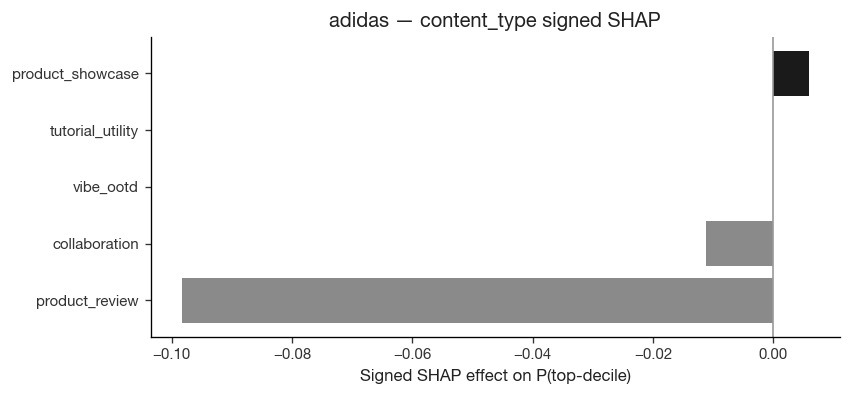

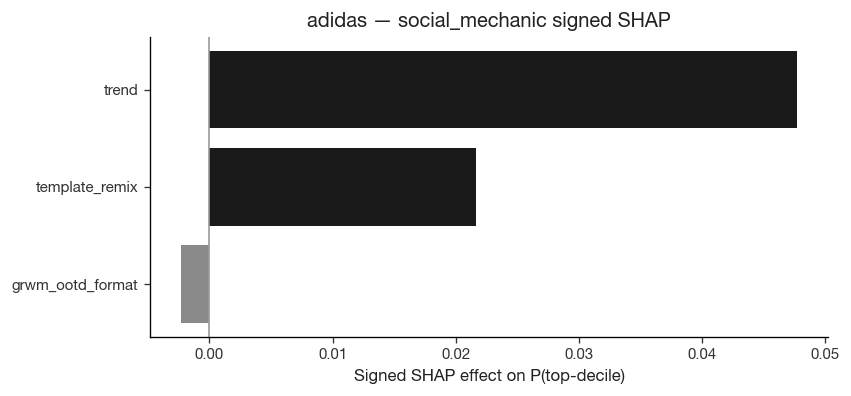

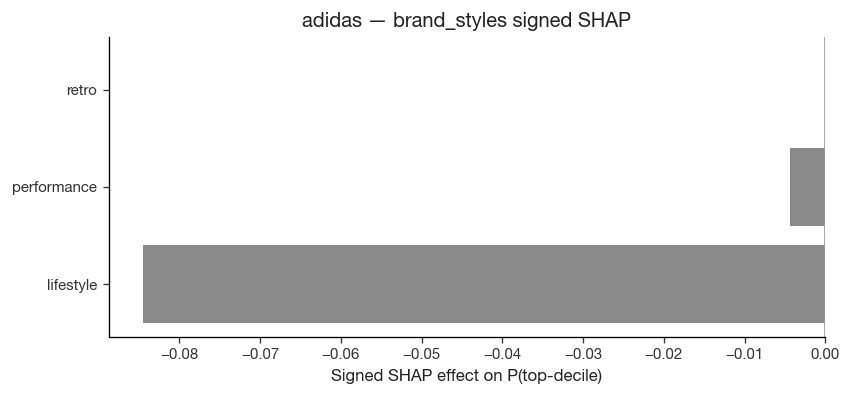

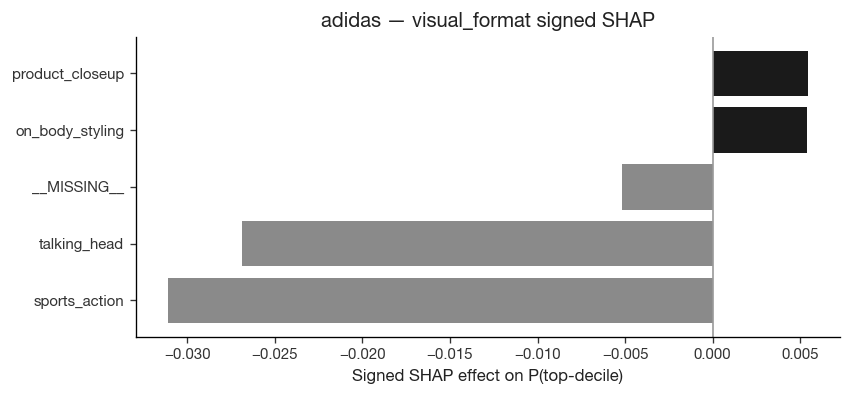

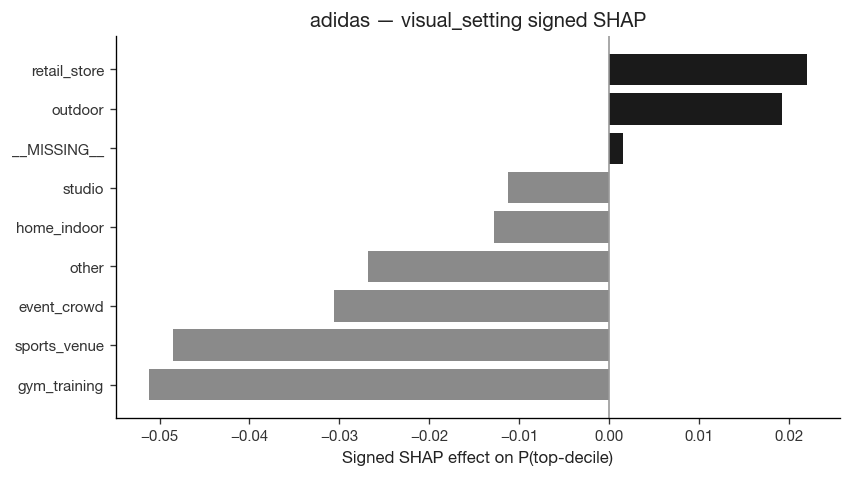

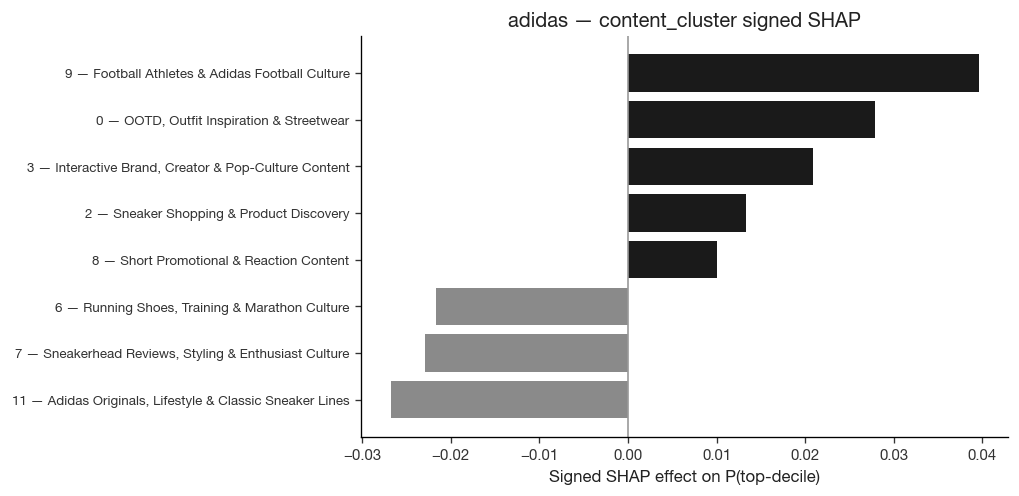

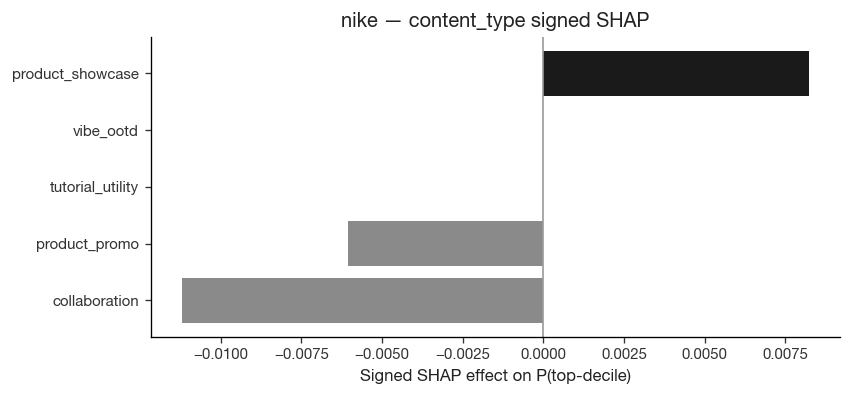

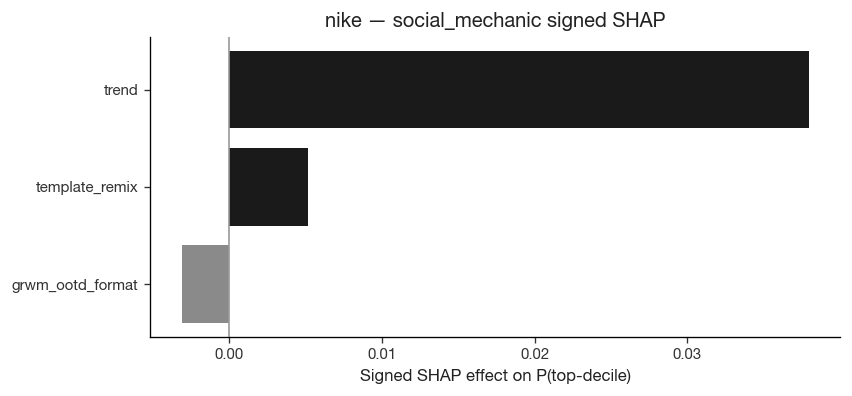

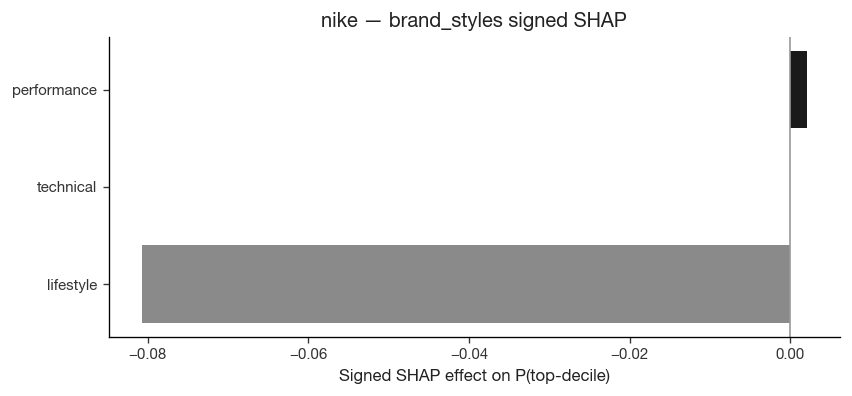

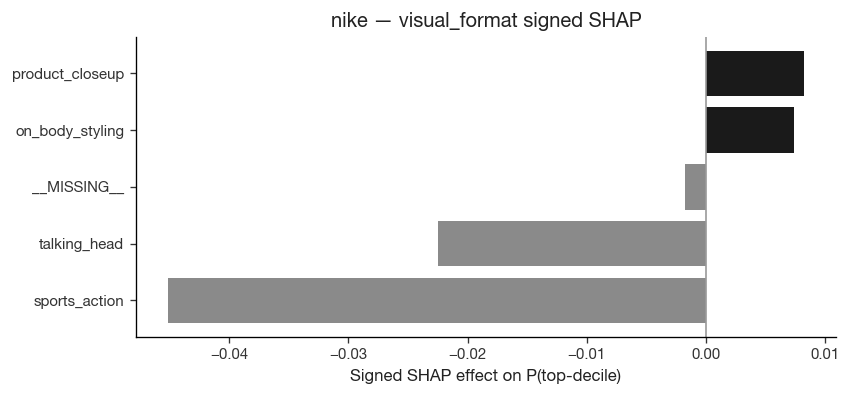

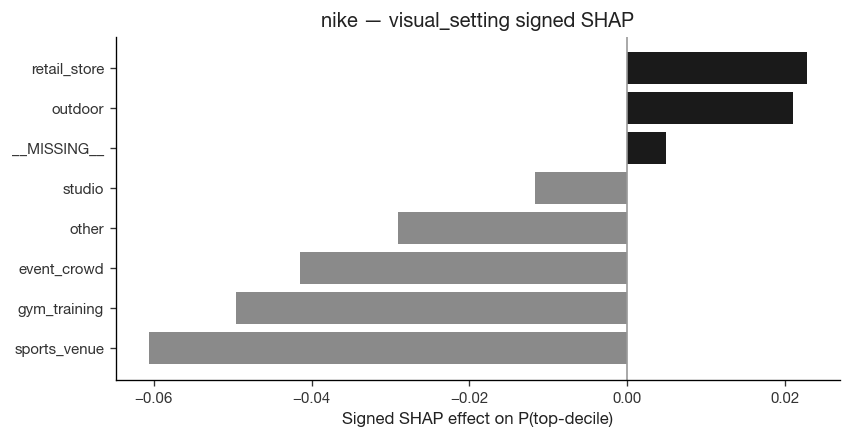

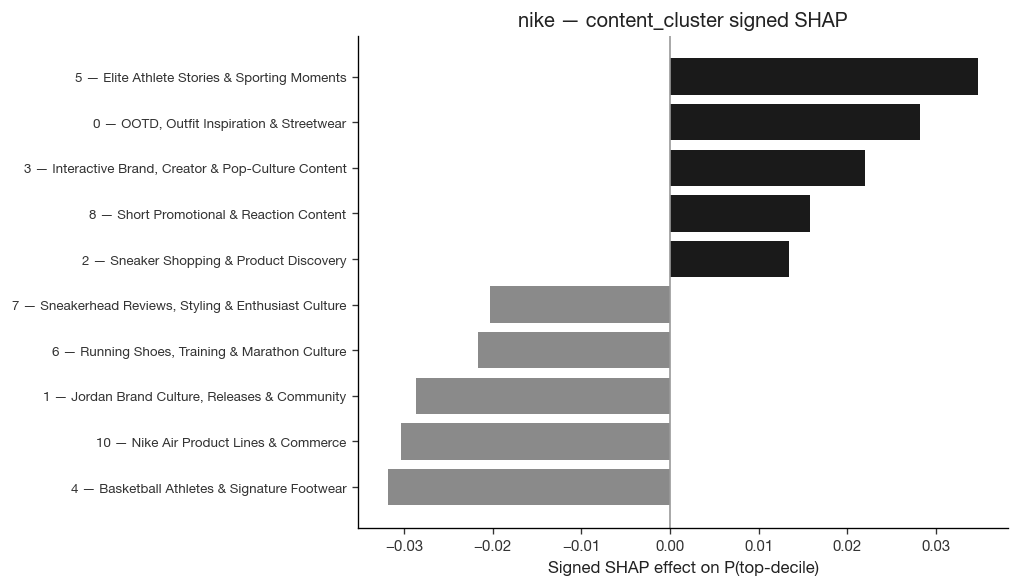

In [1]:
from tiktok_brand.analysis.plots import screening_shap_directions

by = shap_ex["by_brand"]
DIMS = [
    ("content_type_directions", "content_type"),
    ("social_mechanic_directions", "social_mechanic"),
    ("brand_style_directions", "brand_styles"),
    ("visual_format_directions", "visual_format"),
    ("visual_setting_directions", "visual_setting"),
    ("content_cluster_directions", "content_cluster"),
]
figs_brand = []
for brand in ("adidas", "nike"):
    block = by[brand]
    print(f"\n{brand} n_explain={block['n_explain']}")
    for key, title in DIMS:
        sub = block[key]
        if not len(sub):
            print(f"  {title}: (empty)")
            continue
        display(sub[["level", "n", "effect", "direction"]])
        figs_brand.append(
            screening_shap_directions(sub, title=f"{brand}: {title} signed SHAP", top_n=20)
        )
figs_brand


**Read:** Brand-split signed SHAP for taxonomy + CLIP axes + clusters. Small-n levels are noisy; cross-check `02` BRI/uplift before a content bet. Associative only.


## 11. Modeling conclusion: Theme 1 predictive layer

Three-layer Theme 1 architecture (locked):

| Layer | Method | Question |
|-------|--------|----------|
| **Strategy** | Crosstab + within-brand BRI (`02`) | What appears to work for Nike vs Adidas? |
| **Tiering** | `qclass_4` CatBoost | Where does each video sit in the WER spectrum? |
| **Screening (primary)** | `binary_top_q10` + CLIP + tuned CatBoost | Which candidates are most likely in the true top-decile tail? |

**Top-25%** (`binary_top_q25`) is retained as a **robustness / broader-pool** screening result, not the headline.

**Drivers:** §10b/10c SHAP + **§11.0** below (screening drivers vs `02` strategy). `clip_alignment_*` in features; brand-conditional signed SHAP. Associative only, not causal.

---


### 11.0 Drivers vs strategy (crosstab ≠ SHAP)

Theme 1 keeps **two complementary narratives**. Do not merge them into one “what works” list.

| Layer | Notebook | Question | Typical outputs |
|-------|----------|----------|-----------------|
| **Strategy** | `02` crosstab / within-brand BRI | Relative to each brand’s **median** WER, which territories look strong? | Nike tutorial↑, Adidas vibe_ootd↑, collaboration, trend, … |
| **Screening drivers** | `03` §10b/10c SHAP on Top-10% model | What pre-publish signals move **P(top-decile)** after controlling for other features? | Importance families + signed direction (pooled & by brand) |

**Top-10% screening: what the model uses (importance, mean |SHAP| share):**

1. **Visual semantics (CLIP)** + **text semantics (embedding):** largest pooled share (latent; not a single editable knob)
2. **Creator audience / identity:** strongest *structured* lever (`creator_tier`, followers); nano↑ / larger tiers↓ on rate-style top-tail
3. **Caption characteristics**
4. **Video duration** & **post timing** (separate families)
5. **Visual format / setting** (CLIP axes)
6. **Visual–text alignment:** present in the model; higher alignment associates with **lower** P(top) in this sample (associative)

Atomic feature highlights often include: `creator_tier`, `author_follower_count`, `video_duration_sec`, `clip_alignment_max`, plus individual `emb_pca_*` / `vis_pca_*`.

**How to talk about this externally**

- Crosstab → “what appears to work **for Nike vs Adidas** on typical engagement.”
- SHAP importance → “what the **pre-publish screener** relies on to rank extreme-tail potential.”
- SHAP direction (§10c by brand) → “conditional on other features, does this label push P(top) up or down **for that brand**.”
- Never treat SHAP/crosstab as causal lift.

### Executive summary

This analysis examined whether TikTok content performance can be meaningfully anticipated **before publication** using creator, content strategy, textual, visual, and timing features (~4,400 Nike/Adidas videos; modeling frame **n = 4,418**).

**Precise engagement-rate prediction is not the most useful formulation.** Direct regression on weighted engagement rate (WER) only modestly beat a brand-median baseline: CatBoost reduced MAE from ≈0.00493 to ≈0.00479 (~**3%**). Given organic TikTok volatility, that does not support positioning the model as a precise performance forecaster.

A more useful formulation is **content prioritization**: identify a small pool with a substantially higher concentration of future top performers.

**Primary predictive result: Top-10% screening** (train-fold Q90 labels; GroupKFold by `author_id`; CLIP visual PCA; CatBoost params from the Top-25 Lift@10 tune, **reused without re-tuning**):

| Metric | Result |
|--------|--------|
| Lift@5 | **3.10×** |
| Lift@10 | **2.39×** |
| Lift@20 | **2.06×** |
| ROC-AUC | **0.686** |
| Precision@10 | **0.241** |
| Spearman | 0.207 |

Among the 10% of videos with the highest model scores, **24.1%** were actual top-decile performers vs ≈10% baseline prevalence → **≈2.39×** enrichment.

Interpret the predictive component as a **screening / prioritization layer**, not a viral oracle or point engagement predictor. Strategic conclusions about Nike vs Adidas remain grounded primarily in descriptive within-brand analysis (`02`).

---

### 11.1 Modeling objective

**Question:** Can pre-publish information help prioritize content with unusually high engagement potential?

- Outcome: `weighted_engagement_rate` (WER).
- Inputs: creator/account, content type & brand style, social mechanics, visual format/setting, caption structure, CTAs/hooks, sentiment/language, duration, music/timing, text semantics (PCA within fold), CLIP ViT-B/32 visual embeddings (~**84%** coverage; missing handled in-pipeline).
- **Excluded:** all post-publish engagement (views, likes, comments, shares, saves, rates, BRI).

---

### 11.2 Leakage-controlled validation

- **5-fold `GroupKFold` by `author_id`** to generalize to unseen creators.
- Quantile thresholds from **training fold only**. For Top-10%:

$$T_{90}=\operatorname{Quantile}(WER_{train},0.90),\quad Y=1 \text{ iff } WER \ge T_{90}$$

No validation-set or full-dataset quantile defines labels.

---

### 11.3 Why the problem shifted away from exact WER regression

Brand-median MAE ≈0.00493; CatBoost regression ≈0.00479; Spearman ≈0.23. Alternatives (log1p, author priors under unseen-author CV, hierarchical shrinkage, LTR) did not overturn the conclusion:

> Pre-publish features contain signal about **relative** engagement potential, but not enough to reliably estimate **exact** WER magnitude.

Reframe: *“Which videos deserve priority because they are more likely to become unusually strong performers?”*

---

### 11.4 Two complementary modeling tasks

**Tiering (`qclass_4`):** four train-fold quantile classes; expected ordinal score \(\sum_i i\,P(Y=i)\). Acc ≈0.33 (vs ~0.25 random), Macro-F1 ≈0.30, Q4 OvR AUC ≈0.63–0.64, expected-score Spearman ≈0.23. Purpose: coarse Low→Mid→High→Top segmentation and a common relative score, not precise prediction.

**Screening (binary Top-Q):**

| Model | Train threshold | Role |
|-------|-----------------|------|
| **Top-10%** | Q90 | **Primary** headline screening |
| Top-25% | Q75 | Broader high-potential pool / robustness |

Same leak-safe pipeline, CLIP features, and `TUNED_CATBOOST_BINARY_TOP_Q` (tuned on Top-25 Lift@10; **transferred** to Top-10).

---

### 11.5 Primary result: Top-decile screening

Target = WER in top 10% vs train-fold distribution. Rank validation videos by \(P(\text{top10})\).

Precision@10 + Lift@10: ~10% positives by construction → random top-10% pool would contain ~10% true top-decile; model-ranked top 10% contains **24.1%** → **2.39×** Lift@10. More selective top 5% → **3.10×**; expand to 20% → **2.06×**. Signal concentrates near the top of the ranking.

---

### 11.6 Broader screening: Top 25% (robustness)

| Metric | Result |
|--------|--------|
| Lift@5 | 2.41× |
| Lift@10 | **2.33×** |
| Lift@20 | 1.85× |
| ROC-AUC | **0.676** |
| Precision@10 | 0.566 |
| Spearman | 0.280 |

56.6% of model-ranked top 10% are actual Top-25% performers (baseline ~25%) → **≈2.33×** Lift@10. Higher Prec@10 than Top-10 is **not** evidence of superiority (different prevalence/difficulty). Compare on **Lift**. Top-25 answers “broader high-potential pool?”; Top-10 answers “highest priority for breakout performers?”

---

### 11.7 Visual information & hyperparameter tuning

**Top-25 path (where tuning happened):** Lift@10 ≈ **1.94×** (no CLIP) → **2.05×** (+CLIP) → **2.33×** (controlled CatBoost tune, Lift@10 objective, +13.7% relative vs default+CLIP). AUC also improved slightly (+1.4%); further large search stopped (diminishing returns vs CV reuse risk). Interaction features did not beat the simpler CLIP-enabled spec.

**Top-10** uses the **same** tuned params (no separate search).

---

### 11.8 Why accuracy is not primary

~90% negatives on Top-10 → majority-class accuracy is misleading. Business question: if only a small fraction can be reviewed/activated, does the shortlist become richer in high performers? That is **Lift@K**.

**Selection hierarchy:** Lift@10 → ROC-AUC / Precision@10 → Spearman. Acc/F1 diagnostic only.

---

### 11.9 Business interpretation

Do **not** claim “this video will go viral” or treat scores as reliable WER point estimates.

If 100 candidates and capacity for 10: unguided ≈1 top-decile hit expected; model-ranked ≈**2.4** expected hits (2.39× Lift@10).

Workflow: candidates → pre-publish features → model score → ranked shortlist → human/strategic review.

---

### 11.10 Connection to Nike vs Adidas strategy

| Layer | Owner | Role |
|-------|-------|------|
| Strategy | `02` crosstab / BRI | What appears to work |
| Prioritization | `03` screening | Which candidates deserve attention |
| Causality | Future experiments | What actually causes improvement |

Predictive association ≠ causal effect of adopting a feature.

---

### 11.11 Limitations

- n ≈ 4.4k; Top-10 positives are a small minority.
- Much engagement variance is post-publish / latent.
- Visual embeddings ~84% coverage.
- GroupKFold = unseen-author generalization (harder than seen-creator forecast).
- Observational study (not causal).

---

### Final conclusion

Exact WER regression adds little; the same pre-publish signals become useful as **ranking / screening**. The Top-10% model (structured + text + CLIP, unseen-author CV) yields **≈2.39×** Lift@10 and **≈3.10×** Lift@5. Position as **decision-support screening**, not a substitute for judgment.

**Strategy → tiering → screening → experiment.**

### Code entry points

- `run_quantile_class_cv` (tiering)  
- `run_binary_top_q_cv(..., top_q=0.10|0.25, use_visual_embedding=True, catboost_params=TUNED_CATBOOST_BINARY_TOP_Q)` (screening)  
- `TUNED_CATBOOST_BINARY_TOP_Q` / `SCREENING_RECIPES`  
- `rank_models_by_protocol` (Lift@10-first ranking)  
- `screening_roc_curves` / `screening_lift_bars` (diagnostics below)  


### 11.12 Screening diagnostics (OOF)

ROC curves and Lift@K bars for the locked Top-10 (primary) and Top-25 (robustness) CatBoost + CLIP models under author GroupKFold.


Top-10% (primary): Lift@10=2.393  AUC=0.686  Prec@10=0.241
Top-25% (robustness): Lift@10=2.334  AUC=0.675  Prec@10=0.566


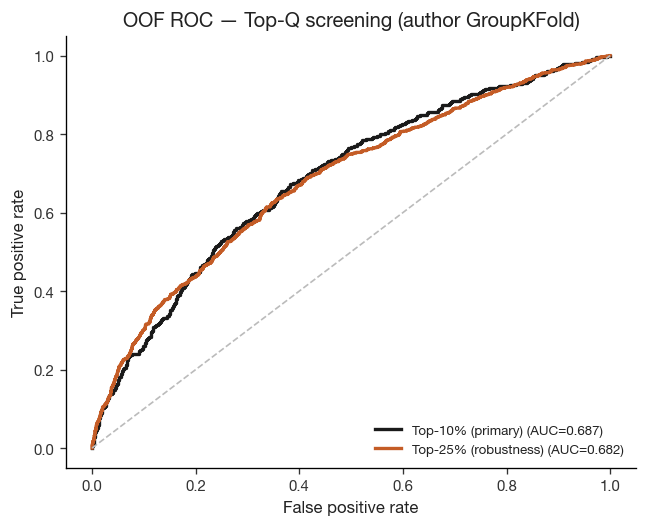

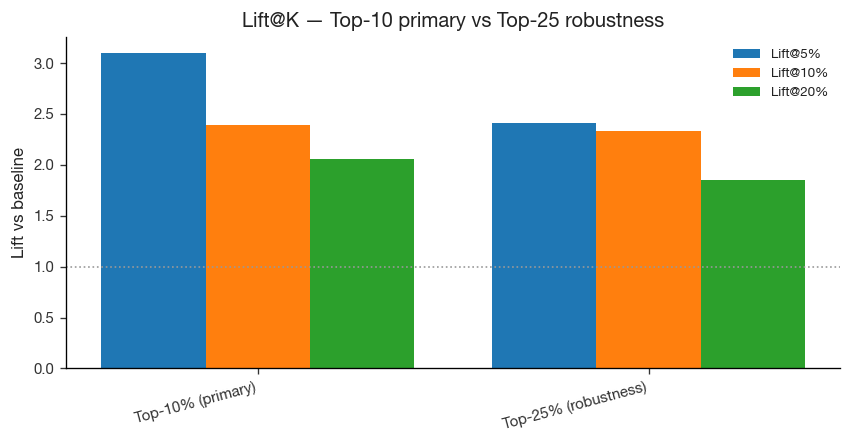

In [1]:
from tiktok_brand.analysis.modeling import (
    TUNED_CATBOOST_BINARY_TOP_Q,
    run_binary_top_q_cv,
)
from tiktok_brand.analysis.plots import screening_lift_bars, screening_roc_curves

# Locked screening recipes: CatBoost + CLIP + tuned params (tuned on Top25, reused for Top10)
_specs = [
    ("Top-10% (primary)", 0.10),
    ("Top-25% (robustness)", 0.25),
]
_curves = []
_lift_rows = []
for label, tq in _specs:
    res = run_binary_top_q_cv(
        data,
        top_q=tq,
        n_splits=5,
        pca_dims=24,
        backends=("catboost",),
        use_visual_embedding=True,
        catboost_params=TUNED_CATBOOST_BINARY_TOP_Q,
    )
    sm = res["catboost"]["summary"]
    _curves.append(
        {
            "label": label,
            "y_true": res["catboost"]["oof_true"],
            "score": res["catboost"]["oof_score"],
        }
    )
    _lift_rows.append(
        {
            "label": label,
            "lift_at_5": sm["lift_at_5_mean"],
            "lift_at_10": sm["lift_at_10_mean"],
            "lift_at_20": sm["lift_at_20_mean"],
        }
    )
    print(
        f"{label}: Lift@10={sm['lift_at_10_mean']:.3f}  "
        f"AUC={sm['auc_mean']:.3f}  Prec@10={sm['precision_at_10_mean']:.3f}"
    )

fig_roc = screening_roc_curves(_curves, title="OOF ROC: Top-Q screening (author GroupKFold)")
fig_lift = screening_lift_bars(_lift_rows, title="Lift@K: Top-10 primary vs Top-25 robustness")
fig_roc, fig_lift
